In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris # pip install scikit-learn
import seaborn as sns

Data: [1 2 2 3 3 3 4 5 5 6 7]
Counts: [1 2 3 1 2 2]
Bin edges: [1. 2. 3. 4. 5. 6. 7.]


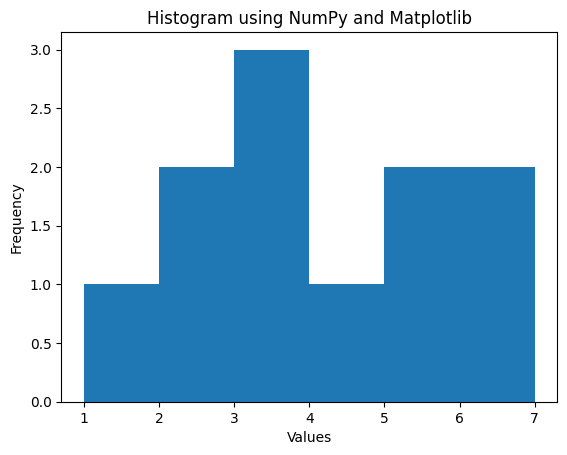

Counts: [1 5 4]
Bin edges: [0 2 4 6]
[1 2 3 4 5 6 7 8] [ 5  6  7  8  9 10 11 12]
Counts:
 [[2. 0. 0. 0.]
 [0. 2. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 2.]]
X bin edges: [1.   2.75 4.5  6.25 8.  ]
Y bin edges: [ 5.    6.75  8.5  10.25 12.  ]


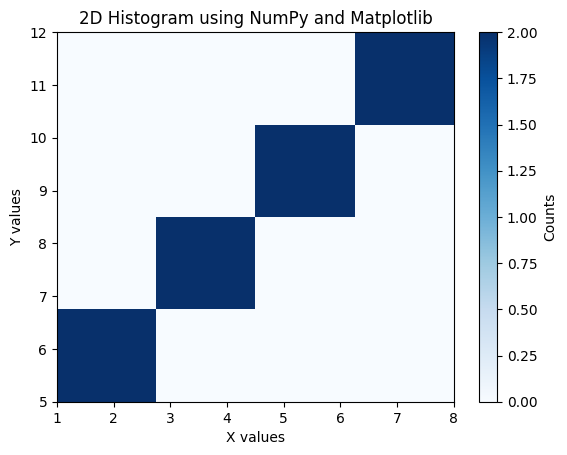

In [2]:
data = np.array([1, 2, 2, 3, 3, 3, 4, 5, 5, 6, 7])
print("Data:", data)
# Create histogram
counts, bin_edges = np.histogram(data, bins=6)

print("Counts:", counts)
print("Bin edges:", bin_edges)
# import matplotlib.pyplot as plt

plt.hist(data, bins=6)
plt.title("Histogram using NumPy and Matplotlib")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()
#################################################################################
# Custom bin edges
bins = [0, 2, 4, 6]
counts, bin_edges = np.histogram(data, bins=bins)

print("Counts:", counts)
print("Bin edges:", bin_edges)
plt.hist(data, bins=bins, edgecolor='black')
#################################################################################
# Two variables
x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([5, 6, 7, 8, 9, 10, 11, 12])

# Create 2D histogram
counts, x_edges, y_edges = np.histogram2d(x, y, bins=4)

print(x, y)
print("Counts:\n", counts)
print("X bin edges:", x_edges)
print("Y bin edges:", y_edges)
plt.hist2d(x, y, bins=4, cmap='Blues')
plt.colorbar(label='Counts')
plt.title("2D Histogram using NumPy and Matplotlib")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.show()
#################################################################################


In [3]:
data = load_iris()
# print(data.keys())
# print(data.feature_names)
df = pd.DataFrame(data.data, columns=data.feature_names)
# print(data.keys())
# print(data.target)

df['Class'] = data.target

# rename the columns
df.rename(columns={'sepal length (cm)': 'SepalLengthCm',
                   'sepal width (cm)': 'SepalWidthCm',
                   'petal length (cm)': 'PetalLengthCm',
                   'petal width (cm)': 'PetalWidthCm'}, inplace=True)
df.head()

def class_label(val):
    if val == 0:
        return 'Setosa'
    elif val == 1:
        return 'Versicolor'
    else:
        return 'Virginica'

df['Class'] = df['Class'].apply(class_label)
df.tail(10)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Class
140,6.7,3.1,5.6,2.4,Virginica
141,6.9,3.1,5.1,2.3,Virginica
142,5.8,2.7,5.1,1.9,Virginica
143,6.8,3.2,5.9,2.3,Virginica
144,6.7,3.3,5.7,2.5,Virginica
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Class          150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Class            0
dtype: int64


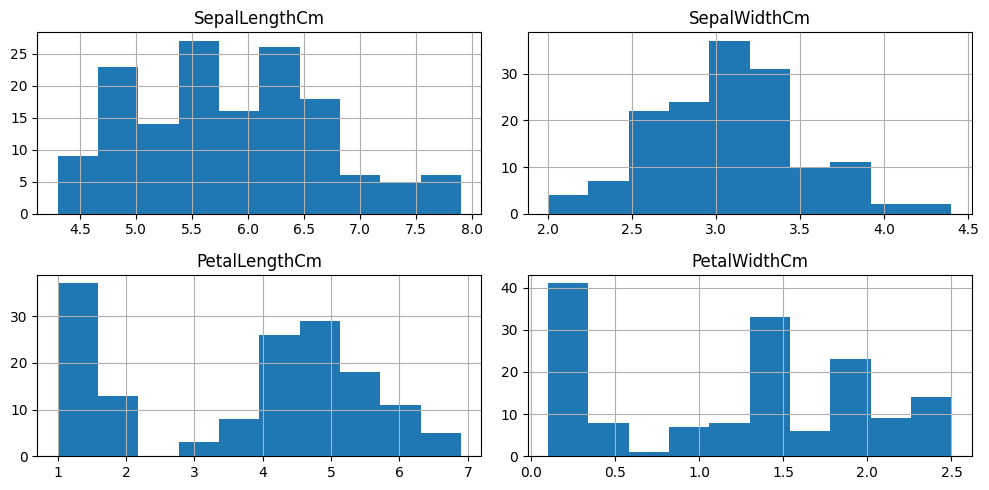

In [ ]:
# Problem Statement: Perform Exploratory Data Analysis (EDA) 
# on the Iris dataset to understand 
# the distribution and relationships 
# of features across different species of Iris flowers.
df.shape
df.info()
df.head()
print(df.isnull().sum())
df.describe()


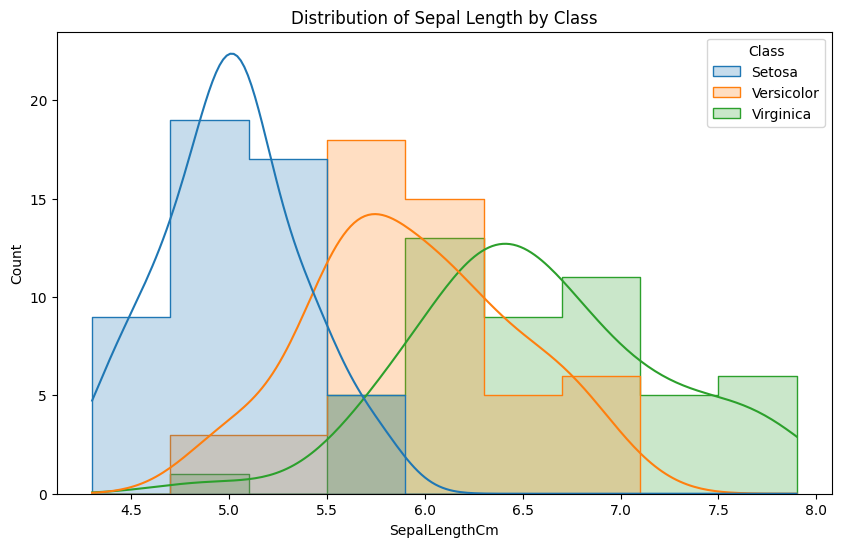

In [22]:
# Univariate analysis (distribution)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='SepalLengthCm', hue='Class', kde=True, element='step')
plt.title('Distribution of Sepal Length by Class')
plt.show() 

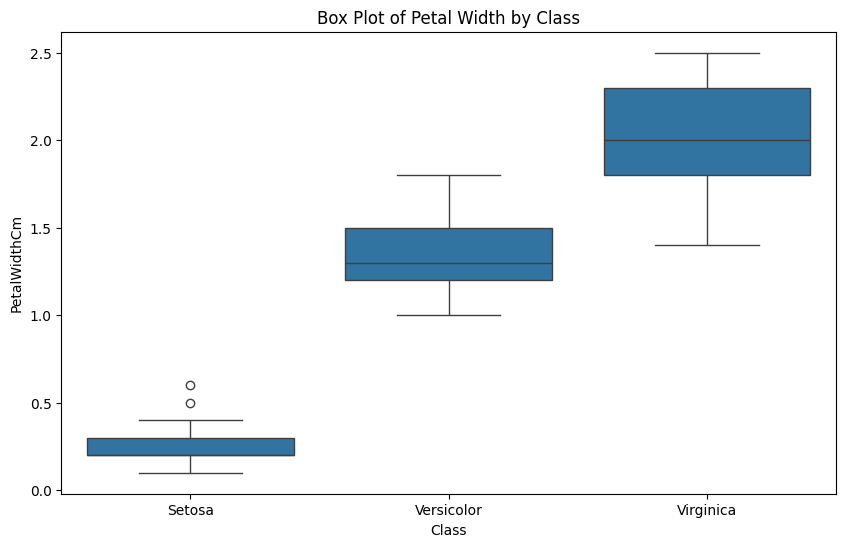

In [23]:
# Box plots (to find outliers)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='PetalWidthCm', data=df)
plt.title('Box Plot of Petal Width by Class')
plt.show()

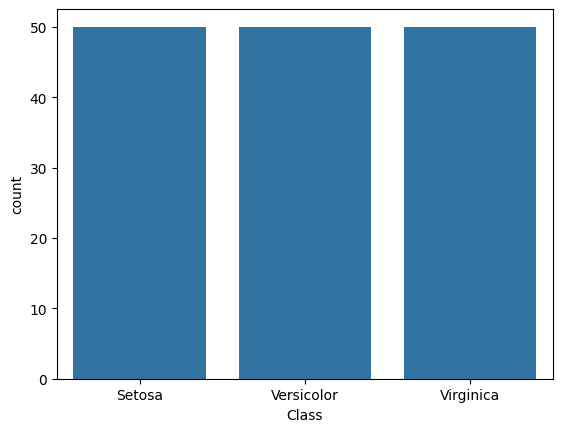

In [28]:
# Species-wise analysis
sns.countplot(x='Class', data=df)
plt.show()

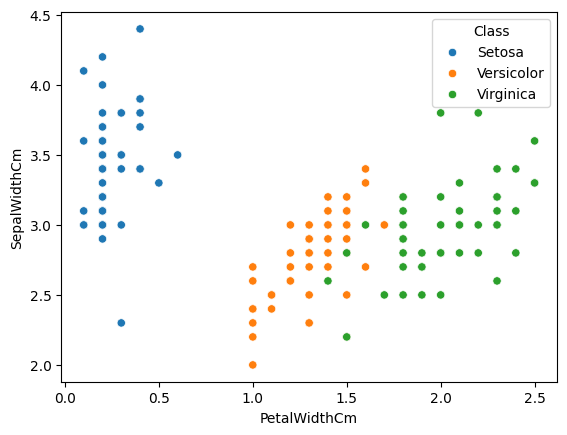

In [29]:
#Bivariate analysis (relationships)
# sns.pairplot(df, hue='Class', markers=['o', 's', 'D'])
# plt.suptitle('Pairplot of Iris Dataset', y=1.02)
# plt.show()

sns.scatterplot(
    x='PetalWidthCm', 
    y='SepalWidthCm', 
    hue='Class', 
    data=df
)
plt.show()

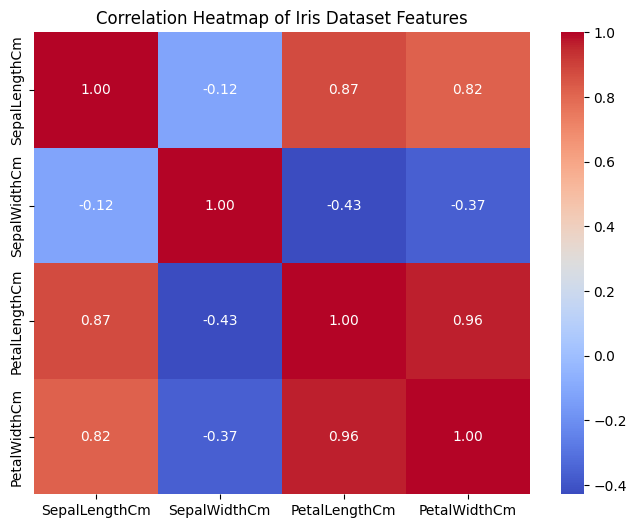

In [30]:
#Correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df.drop('Class', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Iris Dataset Features')
plt.show()

In [13]:
df.Class.value_counts()

Class
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

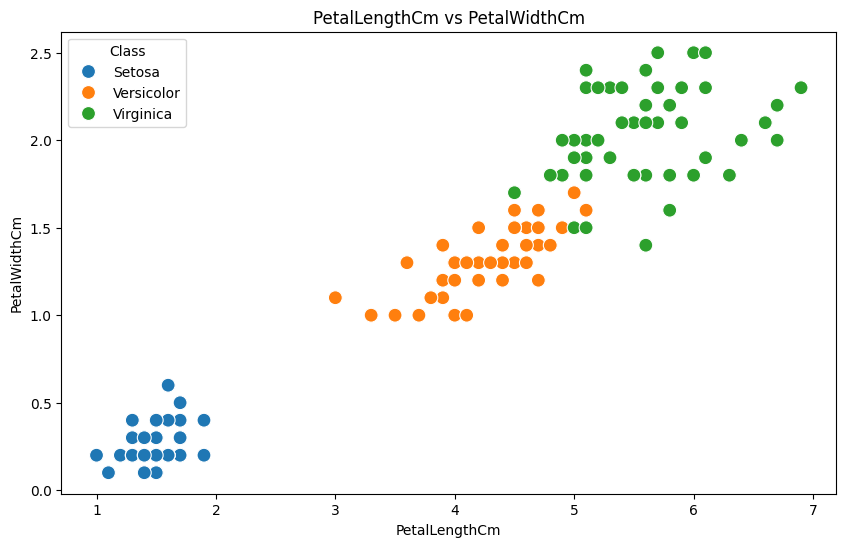

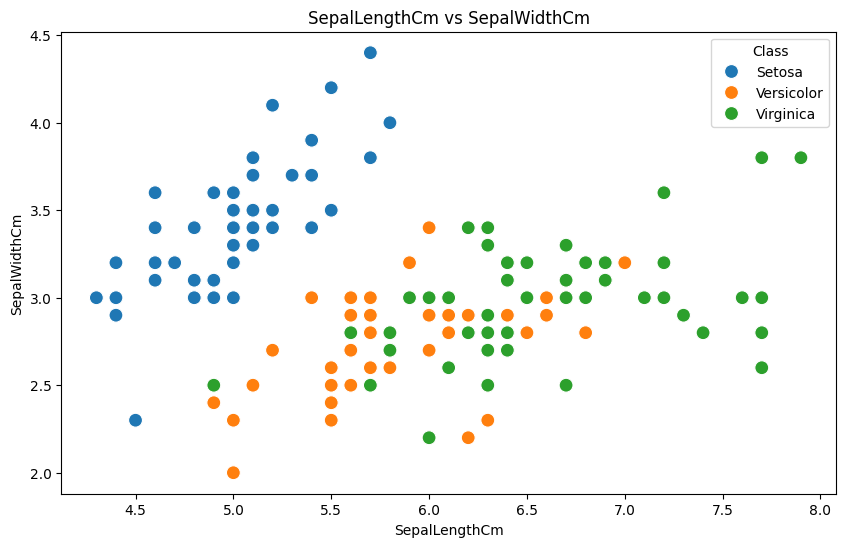

In [14]:
# 2D scatter plot
# wrap inside a function for reuse
def plot_scatter(x_col, y_col):
    plt.figure(figsize=(10,6)) 
    sns.scatterplot(data=df, x=x_col, y=y_col, hue='Class', s=100)
    plt.title(f'{x_col} vs {y_col}')
    plt.show()

plot_scatter('PetalLengthCm', 'PetalWidthCm')
plot_scatter('SepalLengthCm', 'SepalWidthCm')


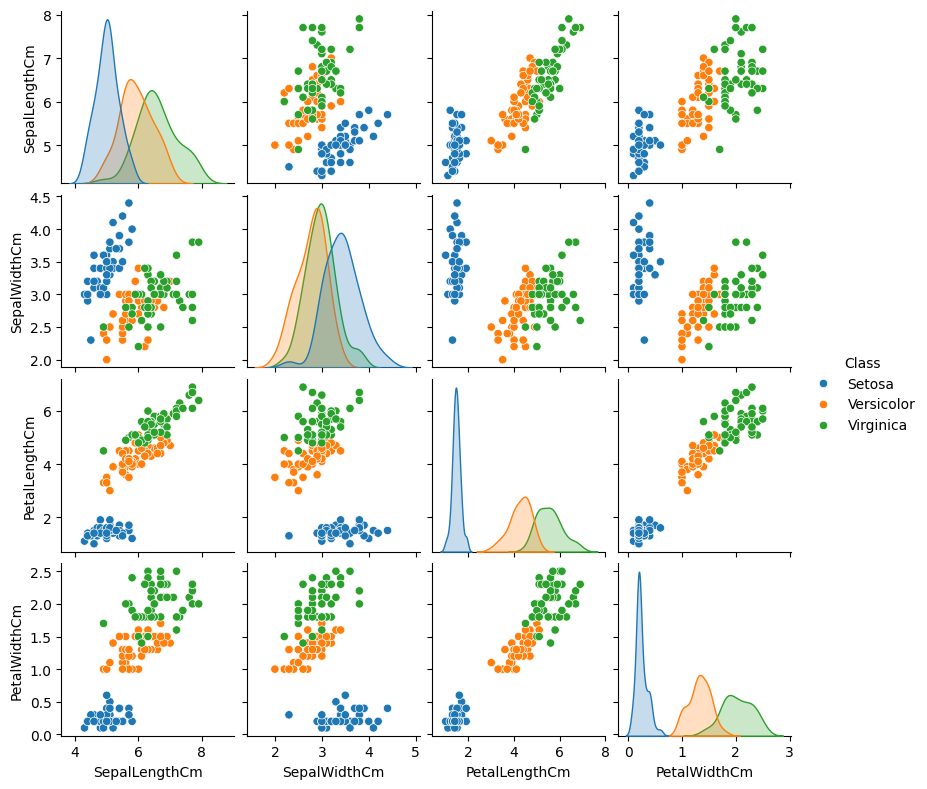

In [4]:
# pairplot
sns.pairplot(df, hue='Class', height=2)
plt.show()

In [5]:
import sys
sys.executable #-m pip install --upgrade nbformat

'/Users/sathish/Documents/akila/ML-learning-materials/ai-ml-akila/ml-env/bin/python'

In [5]:
# 3d scatter plot : plotly
import plotly.express as px  # pip install plotly

fig = px.scatter_3d(df, 
                    x='SepalLengthCm', 
                    y='SepalWidthCm', 
                    z='PetalLengthCm', 
                    color='Class', 
                    size='PetalWidthCm',
                    title='3D Scatter plot of Iris dataset')
fig.show()


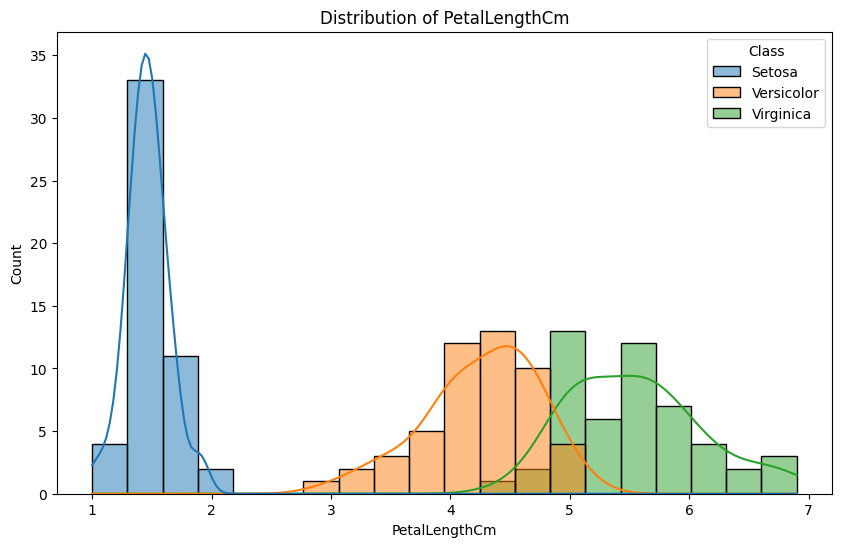

In [ ]:
# 1 D histogram
# plt.figure(figsize=(10,6))
# sns.histplot(data=df, x='SepalLengthCm', hue='Class', kde=True, bins=20)
# plt.title('Distribution of Sepal Length')
# plt.show()

# wrap inside a function for reuse
def plot_histogram(column):
    plt.figure(figsize=(10,6))
    sns.histplot(data=df, x=column, hue='Class', kde=True, bins=20)
    plt.title(f'Distribution of {column}')
    plt.show()
plot_histogram('PetalLengthCm')

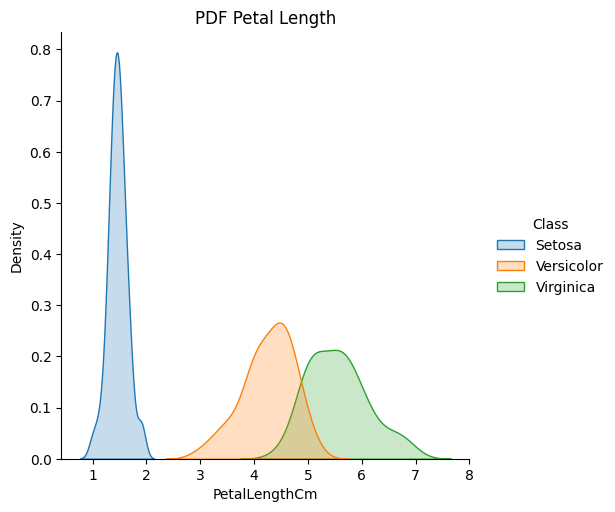

In [ ]:
# using pdf - > cdf
sns.displot(df, x='PetalLengthCm', hue='Class', kind='kde', fill=True)
plt.title('PDF Petal Length')
plt.show()

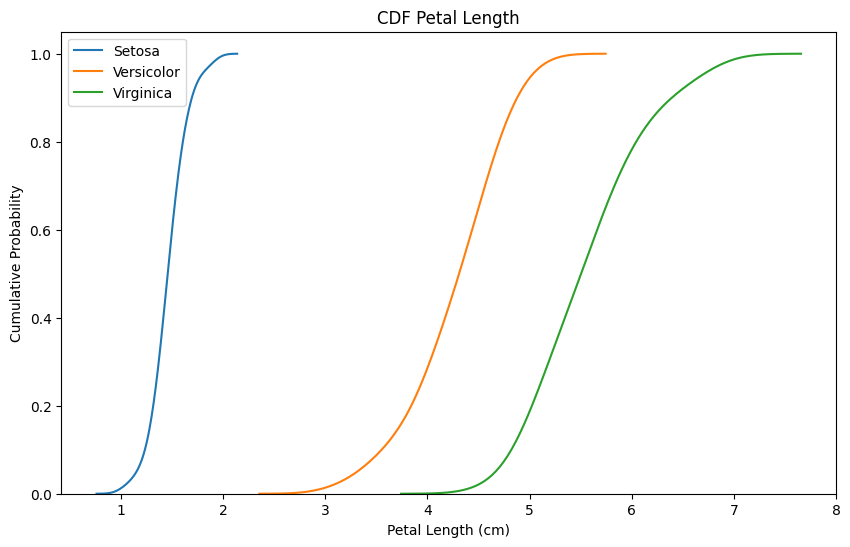

In [ ]:
# for CDF
plt.figure(figsize=(10,6))
for species in df['Class'].unique():
    subset = df[df['Class'] == species]
    sns.kdeplot(subset['PetalLengthCm'], cumulative=True, label=species)
plt.title('CDF Petal Length')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()

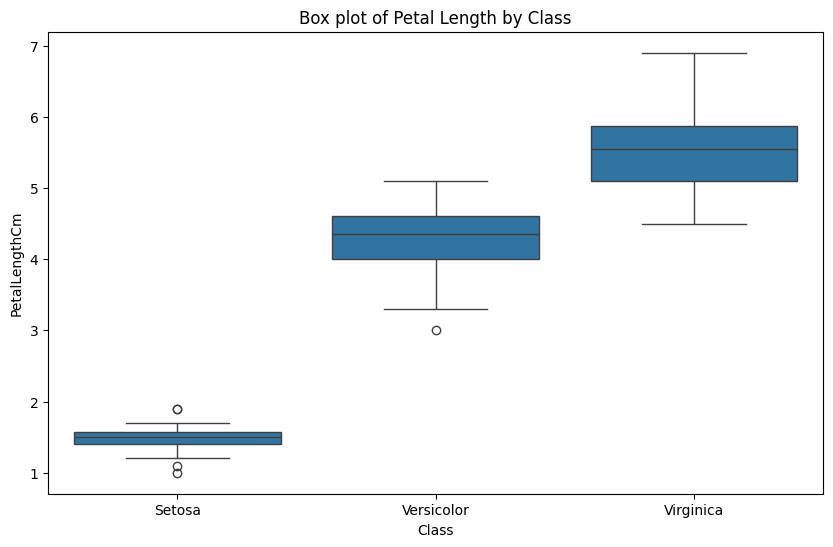

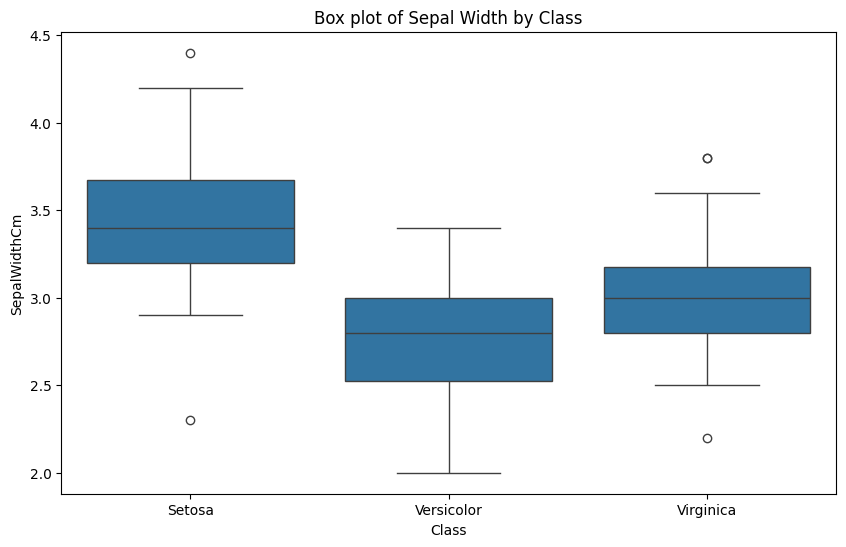

In [ ]:
# box plot
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='PetalLengthCm')
plt.title('Box plot of Petal Length by Class')
plt.show()

# use of box plot to identify outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Class', y='SepalWidthCm')
plt.title('Box plot of Sepal Width by Class')
plt.show()

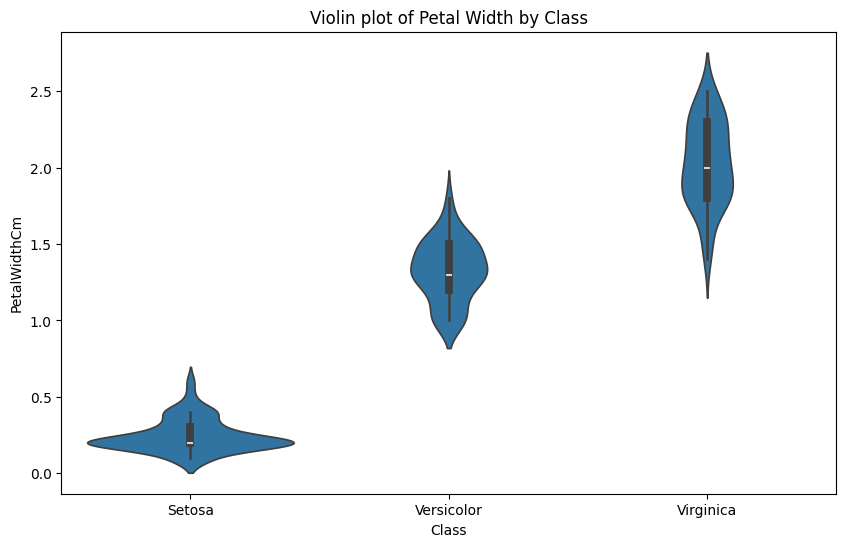

In [ ]:
# voiolin plot
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Class', y='PetalWidthCm')
plt.title('Violin plot of Petal Width by Class')
plt.show()

In [ ]:
# assignment :
# Build Rule engine using if else
# based on feature thresholds
# to classify the species of Iris flower

def classify_iris(row):
    if row['SepalLengthCm'] < 5.0 and row['PetalLengthCm'] < 2.0:
        if row['PetalWidthCm'] < 0.2:
            return 'Setosa'
    elif 5.0 <= row['SepalLengthCm'] < 6.5 and 2.0 <= row['PetalLengthCm'] < 5.0:
        return 'Versicolor'
    else:
        return 'Virginica'

df['PredictedSpecies'] = df.apply(classify_iris, axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Class,PredictedSpecies
0,5.1,3.5,1.4,0.2,Setosa,Virginica
1,4.9,3.0,1.4,0.2,Setosa,None
2,4.7,3.2,1.3,0.2,Setosa,None
3,4.6,3.1,1.5,0.2,Setosa,None
4,5.0,3.6,1.4,0.2,Setosa,Virginica


In [ ]:
# pandas profile report
# pip install ydata-profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Iris Dataset Profiling Report", explorative=True)
profile.to_file("iris_dataset_profile_report.html")

ModuleNotFoundError: No module named 'pkg_resources'

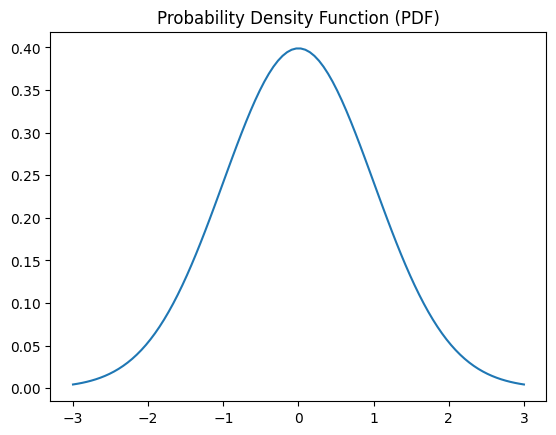

In [7]:
x = np.linspace(-3, 3, 100)
mean = 0
std = 1
pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

# Plot
plt.plot(x, pdf)
plt.title("Probability Density Function (PDF)")
plt.show()
